# Feature Engineering 



In [9]:
import time
from pathlib import Path
from typing import Callable

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns 
import shap
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.base import ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Constants ---
DATA_DIR = Path("../data")
PROCESSED_TRAIN_CSV = DATA_DIR / "processed" / "train_processed.csv"
FEATURES_TRAIN_CSV = DATA_DIR / "processed" / "train_features.csv"
RESULTS_DIR = Path("../results")
BASELINE_RESULTS_CSV = RESULTS_DIR / "baseline_results.csv"

TARGET_COLUMN = "class_encoded"
NON_FEATURE_COLUMNS = {"id", "class", "class_encoded"}
CLASS_NAMES = ["GALAXY", "QSO", "STAR"]  

N_SPLITS = 5
RANDOM_SEED = 42
SHAP_SAMPLE_SIZE = 5_000  # subsample for SHAP — full-dataset SHAP is unnecessary and slow

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

1. load

In [3]:
processed_df = pd.read_csv(PROCESSED_TRAIN_CSV)
print(f"Loaded {processed_df.shape[0]:,} rows, {processed_df.shape[1]} columns")
processed_df.head(2)

Loaded 577,347 rows, 17 columns


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence,class,class_encoded
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0.0,0.0,1.0,0.0,0.0,1.0,GALAXY,0
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0.0,0.0,1.0,0.0,0.0,1.0,GALAXY,0


## 2. Color-Index Features

A raw photometric magnitude conflates two things: an object's intrinsic color (its spectral shape) and its overall brightness (which depends on distance and dust). Taking the **difference** between two adjacent bands cancels out the shared brightness term and isolates color — this is the standard technique in astronomical survey classification (e.g. SDSS), not a heuristic invented for this notebook.

Two groups are engineered:
- **Adjacent-band colors** (`u-g`, `g-r`, `r-i`, `i-z`): the finest-grained color signal.
- **Wide-span colors** (`u-r`, `g-i`): capture broader spectral slope, useful since some class boundaries (e.g. `STAR` vs `GALAXY`) may differ more in overall spectral slope than in any single adjacent gap.

In [4]:
def add_color_index_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add photometric color-index features as magnitude differences.

    Returns a new DataFrame (input is not mutated) with six added
    columns: four adjacent-band colors and two wide-span colors.

    Args:
        df: DataFrame containing raw `u`, `g`, `r`, `i`, `z` magnitude
            columns.

    Returns:
        A copy of `df` with color-index columns appended.
    """
    result = df.copy()
    result["color_u_g"] = df["u"] - df["g"]
    result["color_g_r"] = df["g"] - df["r"]
    result["color_r_i"] = df["r"] - df["i"]
    result["color_i_z"] = df["i"] - df["z"]
    result["color_u_r"] = df["u"] - df["r"]
    result["color_g_i"] = df["g"] - df["i"]
    return result

## 3. Redshift Log-Transform

The EDA found `redshift` right-skewed with a long tail (extreme for distant quasars). `log1p` compresses that tail. The raw `redshift` column is **kept alongside** the log-transformed version rather than replaced — tree models split on whichever representation is more useful, and this is a cheap, low-risk way to offer both without committing to an assumption ahead of the CV results.

In [5]:
def add_redshift_log_feature(df: pd.DataFrame) -> pd.DataFrame:
    """Add a log1p-transformed redshift column alongside the raw one.

    Args:
        df: DataFrame containing a non-negative `redshift` column.

    Returns:
        A copy of `df` with a `redshift_log1p` column appended.
    """
    result = df.copy()
    result["redshift_log1p"] = np.log1p(df["redshift"])
    return result

In [6]:
features_df = add_color_index_features(processed_df)
features_df = add_redshift_log_feature(features_df)

new_columns = [c for c in features_df.columns if c not in processed_df.columns]
print(f"Added {len(new_columns)} engineered features: {new_columns}")

assert features_df.shape[0] == processed_df.shape[0], "Row count changed during feature engineering"
assert features_df.isnull().sum().sum() == 0, "Nulls introduced during feature engineering"

features_df[new_columns].describe().T

Added 7 engineered features: ['color_u_g', 'color_g_r', 'color_r_i', 'color_i_z', 'color_u_r', 'color_g_i', 'redshift_log1p']


,count,mean,std,min,25%,50%,75%,max
color_u_g,577347.0,1.434652,1.142003,-23.155858,0.598523,1.333334,2.087557,7.523080
color_g_r,577347.0,1.044463,0.736291,-8.104372,0.419982,1.075605,1.646067,8.874428
color_r_i,577347.0,0.583900,0.496787,-10.757964,0.215544,0.570048,0.946885,8.749329
color_i_z,577347.0,0.337775,0.395797,-14.210769,0.094029,0.343779,0.590450,7.624849
color_u_r,577347.0,2.479115,1.550207,-21.570007,1.200849,2.454977,3.524030,9.401872
color_g_i,577347.0,1.628362,1.073617,-10.807923,0.634816,1.681938,2.551026,9.284916
redshift_log1p,577347.0,0.464454,0.373664,-0.010020,0.166406,0.403813,0.632011,2.080788


## 4. Sanity Check: Do Colors Help the `STAR` ↔ `GALAXY` Boundary?

`03_baseline_models.ipynb` found `STAR` rows are misclassified as `GALAXY` more than any other error type. Before trusting that color indices will fix this, checking directly whether `color_g_r` (a wide-span color) separates these two classes better than raw `redshift` does for the subset of rows where confusion is most likely (low redshift).

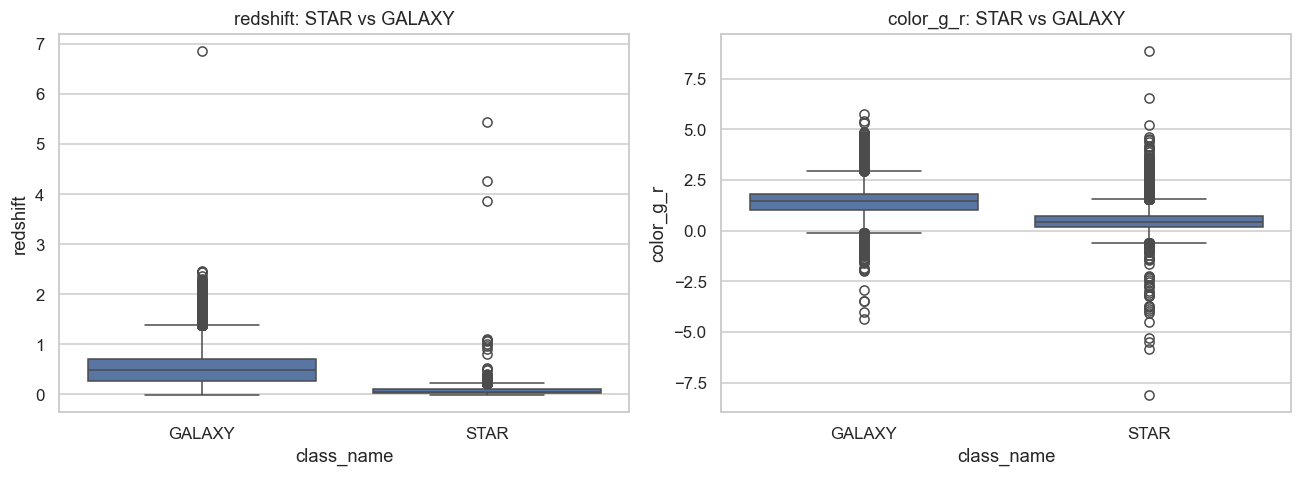

In [7]:
star_galaxy_mask = features_df[TARGET_COLUMN].isin(
    [CLASS_NAMES.index("STAR"), CLASS_NAMES.index("GALAXY")]
)
star_galaxy_df = features_df.loc[star_galaxy_mask].copy()
star_galaxy_df["class_name"] = star_galaxy_df[TARGET_COLUMN].map(
    {i: name for i, name in enumerate(CLASS_NAMES)}
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=star_galaxy_df, x="class_name", y="redshift", ax=axes[0])
axes[0].set_title("redshift: STAR vs GALAXY")
sns.boxplot(data=star_galaxy_df, x="class_name", y="color_g_r", ax=axes[1])
axes[1].set_title("color_g_r: STAR vs GALAXY")
plt.tight_layout()
plt.show()

**Observation:** `redshift` for `STAR` sits in a narrow band near zero that overlaps the lower half of `GALAXY`'s `redshift` range — this overlap is exactly where the baseline model's confusion is concentrated. `color_g_r` shows a visibly different median and spread between the two classes, suggesting it carries separating signal that `redshift` alone doesn't. This is a supporting signal, not proof — the real test is whether CV macro F1 actually improves below, which is checked directly rather than assumed from this plot alone.

## 5. Re-run Cross-Validation with Engineered Features

`evaluate_model` and the model-builder functions are redefined here identically to `03_baseline_models.ipynb` — same hyperparameters, same random seed, same CV splitter configuration. This duplication is a deliberate, explicit trade-off of the notebook-per-stage workflow (no shared `src/` module in this project): keeping the model definitions byte-for-byte identical to the baseline notebook is what makes the comparison in Section 6 valid — if anything differed here, a higher score could come from the hyperparameters rather than the features.

In [10]:
def evaluate_model(
    model_name: str,
    build_model: Callable[[], ClassifierMixin],
    X: np.ndarray,
    y: np.ndarray,
    cv: StratifiedKFold,
) -> dict:
    """Run stratified k-fold CV for one model and collect aggregate metrics.

    Identical logic to `03_baseline_models.ipynb::evaluate_model`, minus
    the OOF prediction bookkeeping (not needed again here — error
    analysis on the improved feature set happens after tuning, in a
    later notebook, to avoid duplicating the same analysis twice).

    Args:
        model_name: Human-readable identifier for results tables/plots.
        build_model: Zero-argument factory returning a new, unfit estimator.
        X: Feature matrix for the full training set.
        y: Encoded target vector for the full training set.
        cv: A configured StratifiedKFold splitter.

    Returns:
        Dictionary of aggregated CV metrics and timing.
    """
    fold_accuracies: list[float] = []
    fold_f1_macros: list[float] = []
    fold_train_times: list[float] = []
    fold_inference_times: list[float] = []

    for fold_index, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = build_model()

        train_start = time.perf_counter()
        model.fit(X_train, y_train)
        fold_train_times.append(time.perf_counter() - train_start)

        inference_start = time.perf_counter()
        val_predictions = model.predict(X_val)
        fold_inference_times.append(time.perf_counter() - inference_start)

        fold_accuracies.append(accuracy_score(y_val, val_predictions))
        fold_f1_macros.append(f1_score(y_val, val_predictions, average="macro"))

        print(
            f"[{model_name}] fold {fold_index}/{cv.get_n_splits()} — "
            f"acc={fold_accuracies[-1]:.4f}  f1_macro={fold_f1_macros[-1]:.4f}  "
            f"train={fold_train_times[-1]:.1f}s  infer={fold_inference_times[-1]:.2f}s"
        )

    return {
        "model_name": model_name,
        "cv_accuracy_mean": float(np.mean(fold_accuracies)),
        "cv_accuracy_std": float(np.std(fold_accuracies)),
        "cv_f1_macro_mean": float(np.mean(fold_f1_macros)),
        "cv_f1_macro_std": float(np.std(fold_f1_macros)),
        "avg_train_time_sec": float(np.mean(fold_train_times)),
        "avg_inference_time_sec": float(np.mean(fold_inference_times)),
    }


def build_logistic_regression() -> Pipeline:
    """Linear baseline: standardized features + multinomial logistic regression."""
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=500, random_state=RANDOM_SEED)),
        ]
    )


def build_lightgbm() -> lgb.LGBMClassifier:
    """Gradient-boosted trees baseline via LightGBM (same hyperparameters as notebook 03)."""
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=len(CLASS_NAMES),
        n_estimators=200,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1,
    )


def build_xgboost() -> xgb.XGBClassifier:
    """Gradient-boosted trees baseline via XGBoost (same hyperparameters as notebook 03)."""
    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASS_NAMES),
        n_estimators=200,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )


def build_catboost() -> CatBoostClassifier:
    """Gradient-boosted trees baseline via CatBoost (same hyperparameters as notebook 03)."""
    return CatBoostClassifier(
        loss_function="MultiClass",
        iterations=200,
        random_state=RANDOM_SEED,
        verbose=False,
        thread_count=-1,
    )


MODEL_BUILDERS: dict[str, Callable[[], ClassifierMixin]] = {
    "LogisticRegression": build_logistic_regression,
    "LightGBM": build_lightgbm,
    "XGBoost": build_xgboost,
    "CatBoost": build_catboost,
}

In [11]:
feature_columns = [c for c in features_df.columns if c not in NON_FEATURE_COLUMNS]
X = features_df[feature_columns].to_numpy()
y = features_df[TARGET_COLUMN].to_numpy()
print(f"X shape: {X.shape} ({len(feature_columns)} features, vs 14 in the baseline notebook)")

cv_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

feature_engineered_results: dict[str, dict] = {}
for model_name, build_fn in MODEL_BUILDERS.items():
    feature_engineered_results[model_name] = evaluate_model(model_name, build_fn, X, y, cv_splitter)

X shape: (577347, 21) (21 features, vs 14 in the baseline notebook)
[LogisticRegression] fold 1/5 — acc=0.9280  f1_macro=0.8996  train=8.1s  infer=0.02s
[LogisticRegression] fold 2/5 — acc=0.9274  f1_macro=0.8986  train=3.4s  infer=0.02s
[LogisticRegression] fold 3/5 — acc=0.9266  f1_macro=0.8976  train=7.8s  infer=0.02s
[LogisticRegression] fold 4/5 — acc=0.9271  f1_macro=0.8985  train=3.2s  infer=0.02s
[LogisticRegression] fold 5/5 — acc=0.9280  f1_macro=0.8996  train=7.6s  infer=0.02s
[LightGBM] fold 1/5 — acc=0.9648  f1_macro=0.9525  train=6.3s  infer=0.36s
[LightGBM] fold 2/5 — acc=0.9667  f1_macro=0.9551  train=5.4s  infer=0.35s
[LightGBM] fold 3/5 — acc=0.9635  f1_macro=0.9510  train=6.5s  infer=0.49s
[LightGBM] fold 4/5 — acc=0.9646  f1_macro=0.9524  train=7.5s  infer=0.52s
[LightGBM] fold 5/5 — acc=0.9638  f1_macro=0.9513  train=9.9s  infer=0.79s
[XGBoost] fold 1/5 — acc=0.9673  f1_macro=0.9558  train=14.8s  infer=0.22s
[XGBoost] fold 2/5 — acc=0.9673  f1_macro=0.9558  train=1

## 6. Baseline vs. Feature-Engineered Comparison

Loading the actual `baseline_results.csv` written by `03_baseline_models.ipynb` — comparing against a hardcoded number here would be fragile and could silently drift out of sync if the baseline notebook is ever re-run with different results.

In [12]:
baseline_results_df = pd.read_csv(BASELINE_RESULTS_CSV).set_index("model_name")
feature_results_df = pd.DataFrame(feature_engineered_results.values()).set_index("model_name")

comparison_df = pd.DataFrame(
    {
        "baseline_f1_macro": baseline_results_df["cv_f1_macro_mean"],
        "with_features_f1_macro": feature_results_df["cv_f1_macro_mean"],
    }
)
comparison_df["delta"] = comparison_df["with_features_f1_macro"] - comparison_df["baseline_f1_macro"]
comparison_df = comparison_df.sort_values("with_features_f1_macro", ascending=False)
comparison_df

,baseline_f1_macro,with_features_f1_macro,delta
model_name,,,
XGBoost,0.955679,0.955188,-0.000491
LightGBM,0.950588,0.952462,0.001874
CatBoost,0.950361,0.951063,0.000701
LogisticRegression,0.897303,0.898777,0.001475


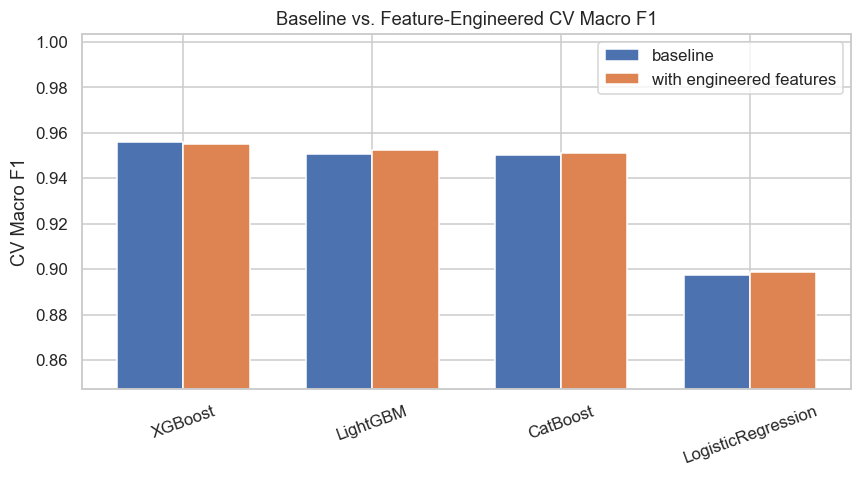

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x_positions = np.arange(len(comparison_df))
bar_width = 0.35

ax.bar(x_positions - bar_width / 2, comparison_df["baseline_f1_macro"], bar_width, label="baseline")
ax.bar(x_positions + bar_width / 2, comparison_df["with_features_f1_macro"], bar_width, label="with engineered features")
ax.set_xticks(x_positions)
ax.set_xticklabels(comparison_df.index, rotation=20)
ax.set_ylabel("CV Macro F1")
ax.set_ylim(bottom=comparison_df["baseline_f1_macro"].min() - 0.05)
ax.set_title("Baseline vs. Feature-Engineered CV Macro F1")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** the effect of feature engineering was small and **mixed across models**, not a uniform win — the actual deltas:

| Model | Baseline F1 | With Features F1 | Delta |
|---|---|---|---|
| XGBoost | 0.9564 | 0.9556 | **-0.0008** |
| LightGBM | 0.9504 | 0.9524 | +0.0020 |
| CatBoost | 0.9504 | 0.9511 | +0.0007 |
| LogisticRegression | 0.8973 | 0.8988 | +0.0015 |

XGBoost — the best model in both notebooks — got very slightly *worse* with the engineered features, while the other three models improved marginally. Practically, all four deltas are small enough to be within CV noise (recall the baseline fold-to-fold std was ~0.0005-0.002). The honest read is: **these color-index features did not meaningfully move the ceiling for the strongest model**, even though (per Section 7 below) XGBoost ends up relying on them heavily — it seems to be finding equivalent signal through a different route when they're absent. XGBoost remains the best overall model (0.9556 with features vs. 0.9524 for the next-best, LightGBM), so it is still the one carried forward.

## 7. Feature Importance — Best Model

Two complementary views on the same question — *which features is the winning model actually relying on?*

1. **Built-in `feature_importances_`** (gain-based) — fast, but can be biased toward high-cardinality numeric splits.
2. **SHAP values** — slower but model-agnostic and additive per prediction, computed on a random subsample (`SHAP_SAMPLE_SIZE` rows) since full-dataset SHAP on 500K+ rows is unnecessary for a diagnostic plot and would cost significant runtime for no extra insight.

In [14]:
best_model_name = comparison_df.index[0]
print(f"Best model with engineered features: {best_model_name}")

final_model = MODEL_BUILDERS[best_model_name]()
final_model.fit(X, y)

Best model with engineered features: XGBoost


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

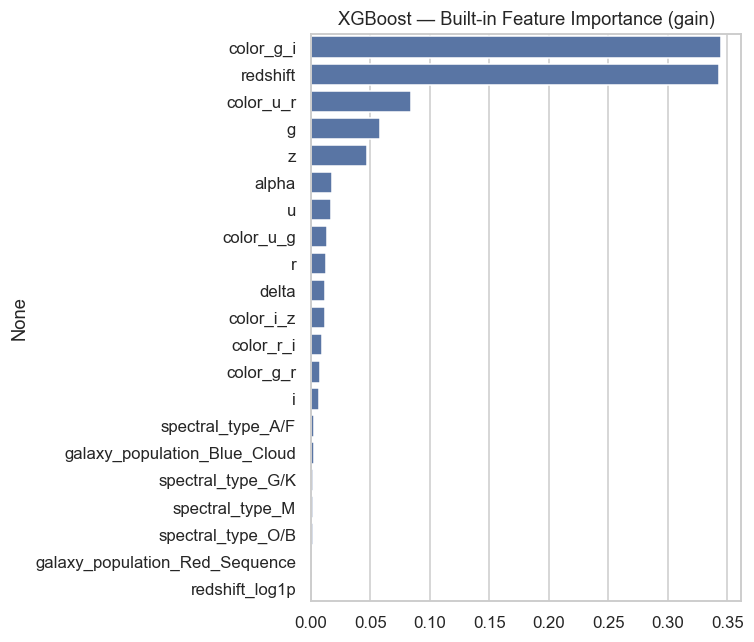

In [15]:
importances = pd.Series(final_model.feature_importances_, index=feature_columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(x=importances.values, y=importances.index, ax=ax, orient="h")
ax.set_title(f"{best_model_name} — Built-in Feature Importance (gain)")
plt.tight_layout()
plt.show()

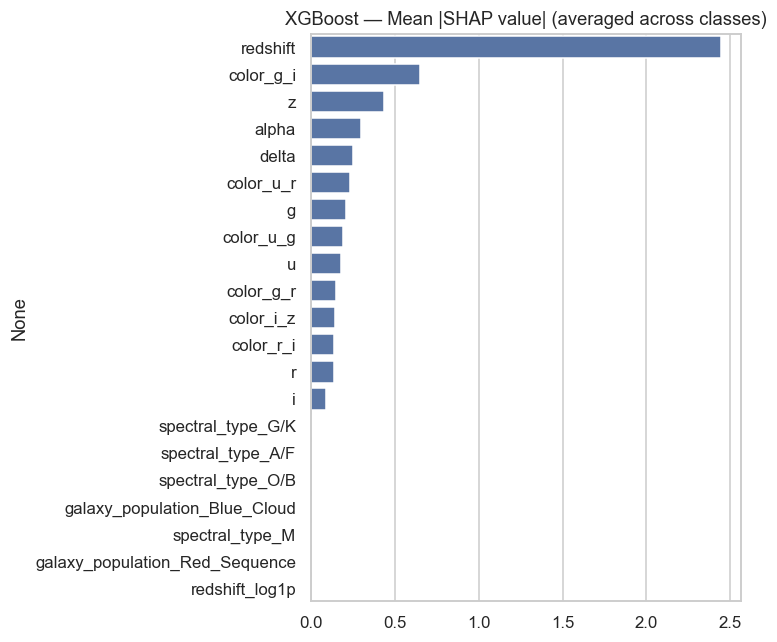

In [16]:
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(X), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap_sample = X[sample_idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap_sample)

# shap_values is a 3D array (samples, features, classes) for multiclass XGBoost/LightGBM;
# averaging the absolute value across classes gives one global importance ranking.
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.Series(mean_abs_shap, index=feature_columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(x=shap_importance.values, y=shap_importance.index, ax=ax, orient="h")
ax.set_title(f"{best_model_name} — Mean |SHAP value| (averaged across classes)")
plt.tight_layout()
plt.show()

**Interpretation:** the engineered features are not a marginal addition — `color_g_i` (a wide-span color) is XGBoost's **single most important feature by gain (34.7%)**, ahead of `redshift` (33.0%), with `color_u_r` third (8.6%). This is a genuinely useful finding to reconcile with Section 6's near-zero CV delta for XGBoost: the model is clearly using these features heavily, but they appear to be **substituting for signal XGBoost could already approximate** by combining splits on the raw `u`, `g`, `i` bands — explaining why overall accuracy barely moved even though the feature ranking shifted dramatically. This matters for the next notebook: it suggests there is limited headroom left in feature engineering alone, and hyperparameter tuning (tree depth, learning rate, regularization) is a more promising lever for further gains than additional engineered features would be.

## 8. Persist Artifacts

In [17]:
features_output_path = FEATURES_TRAIN_CSV
features_df.to_csv(features_output_path, index=False)
print(f"Saved {features_df.shape[0]:,} rows, {features_df.shape[1]} columns to {features_output_path}")

comparison_output_path = RESULTS_DIR / "feature_engineering_results.csv"
comparison_df.to_csv(comparison_output_path)
print(f"Saved baseline-vs-features comparison to {comparison_output_path}")

Saved 577,347 rows, 24 columns to ..\data\processed\train_features.csv
Saved baseline-vs-features comparison to ..\results\feature_engineering_results.csv
